## IMDB Sentiment Classification with LSTM

### Summary

In this project I built a **neural network model** that **classifies movie reviews** from the **IMDB dataset as positive or 
negative** using an **LSTM architecture**. 

The project demonstrates **deep learning model development**, **evaluation**, and **custom text inference**.

It uses Python, Matplotlib for plotting, TensorFlow and Keras for building the deep neural network.

### Dataset Description 
The **IMDB Movie Reviews** dataset is provided by `tensorflow.keras.datasets`. 

- It contains **25,000 preprocessed reviews** labeled as **positive or negative**.
- Each **review** is represented as a **sequence of integers**, where each integer corresponds to a word index ranked by frequency 
in the training set.
- When loading the dataset, the **num_words** parameter controls the vocabulary size — i.e., the **maximum number of most frequent 
words** to keep. Words outside this range are replaced with the **oov_char (out-of-vocabulary token)**. 

### Import libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

### 1. Read IMDB dataset into training and testing

The **num_words** parameter is set to limit the vocabulary size to the **10,000 most frequent words**.

We will also set the fixed lenght of the input sequences, **max_len=200**, and the size of the embedding vector for each 
token, **embedding_dim=64**.

In [2]:
# Parameters
num_words = 10000    # number of unique tokens in the vocabulary
max_len = 200        # fixed length of input sequences
embedding_dim = 64   # size of the embedding vector for each token


# Load IMDB dataset with a vocabulary size of 10,000
num_words = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

print(f"Training samples: {len(x_train)}")
print(f"Max word index in data: {max(max(seq) for seq in x_train)}")

Training samples: 25000
Max word index in data: 9999


Both **training and testing** sets contain **25,000** samples **each**.

#### Word index mapping

As mentioned in the dataset description, each review is pre-encoded as integer sequences. Below it is created a **dictionary that
maps words to integer index**, then it is defined a **function that decodes data**.

In [3]:
# Check the data by printing the first record
print(x_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [4]:
# Dictionary mapping words to an integer index
word_index = imdb.get_word_index()

# Reverse mapping: index → word. The first indices are reserved
reverse_word_index = {index + 3: word for word, index in word_index.items()}
reverse_word_index[1] = "[START]"
reverse_word_index[2] = "[OOV]"
reverse_word_index[0] = "[PAD]"

# Define function to decode data
def decode_review(text):
    return ' '.join([reverse_word_index.get(i, '?') for i in text])

# Decode the first sample review
decode_review(x_train[0])

"[START] this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert [OOV] is an amazing actor and now the same being director [OOV] father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for [OOV] and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also [OOV] to the two little boy's that played the [OOV] of norman and paul they were just brilliant children are often left out of the [OOV] list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for wh

### 2. Prepare dataset

The **input sequences** need to be modified so they all have the **same length for modeling**. 

In [5]:
# Pad sequences to ensure uniform length (max_len = 200) 
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

### 3. Build the LSTM model

The project uses a custom **LSTM**‑based neural network with an **Embedding** layer, recurrent dropout, and **Dense** layers for binary classification.
This architecture is designed to capture sequential patterns in text while maintaining generalization through dropout.

**Model Architecture**
- **Embedding** (input_dim=10000, output_dim=64)  
- **LSTM** (units=64, dropout=0.2, recurrent_dropout=0.2) 
- **Dense** (units=32, activation='relu')
- **Dense** (units=1, activation='sigmoid')

**Training**
- **Loss:** Binary Crossentropy  
- **Optimizer:** Adam  
- **Epochs:** 3  
- **Batch Size:** 256  
- **Validation Split:** 20%  

In [6]:
# Build LSTM model

# num_words = 10000          
# embedding_dim = 64     

model = models.Sequential([
    layers.Embedding(input_dim=num_words, 
                     output_dim=embedding_dim),
    layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")                      
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train
history = model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

# Check model summary
print(model.summary())

Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 177ms/step - accuracy: 0.6972 - loss: 0.5687 - val_accuracy: 0.8134 - val_loss: 0.4195
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 171ms/step - accuracy: 0.8532 - loss: 0.3519 - val_accuracy: 0.8342 - val_loss: 0.3723
Epoch 3/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.8886 - loss: 0.2833 - val_accuracy: 0.8574 - val_loss: 0.3522


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 64)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,025,413 (7.73 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,350,276 (5.15 MB)

None


**Training accuracy** improves steadily, reaching **88.86%** on the final epoch.

In [7]:
# Evaluate
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.8581


The model achieved a **test accuracy** of **85.81%** on unseen data.

#### Show some predictions

In [8]:
# Example prediction 1 (positive)
review_index = 10
prediction = model.predict(x_test[review_index:review_index + 1])[0][0]
label = "positive" if prediction >= 0.5 else "negative"

print(f"Predicted sentiment: {label}")
print(f"Prediction probability: {prediction:.4f}")
print(f"True label: {'positive' if y_test[review_index] == 1 else 'negative'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Predicted sentiment: positive
Prediction probability: 0.9831
True label: positive


In [9]:
# Example  prediction 2 (negative)
review_index = 13
prediction = model.predict(x_test[review_index:review_index + 1])[0][0]
label = "positive" if prediction >= 0.5 else "negative"

print(f"Predicted sentiment: {label}")
print(f"Prediction probability: {prediction:.4f}")
print(f"True label: {'positive' if y_test[review_index] == 1 else 'negative'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted sentiment: negative
Prediction probability: 0.0195
True label: negative


The predictions are corect, both positive or negative, for the tested samples.

### 4. Plot training history

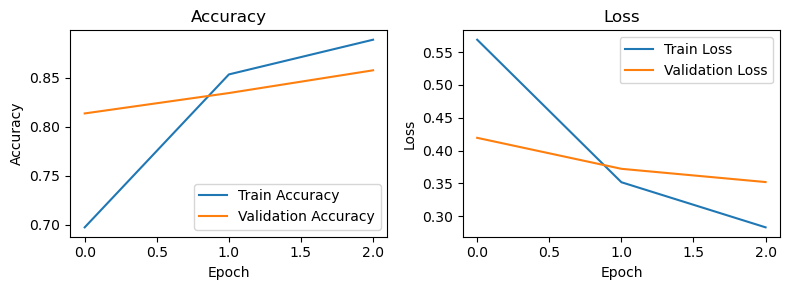

In [10]:
# Plot training history (train and validation accuracy)
plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], 
         label="Train Accuracy")
plt.plot(history.history["val_accuracy"], 
         label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], 
         label="Train Loss")
plt.plot(history.history["val_loss"], 
         label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

The **training curves** show a good learning pattern:  
- **Accuracy:** Training accuracy rises from ~0.69 to ~0.88, while validation accuracy increases from ~0.80 to ~0.86. Both 
    curves improve steadily and stay close to each other, indicating good generalization.  
- **Loss:** Training loss decreases from ~0.55 to ~0.30, and validation loss decreases from ~0.42 to ~0.35. The gap between 
    the curves remains small, suggesting the model is not overfitting.  

Together, these curves show that the model is learning efficiently and maintaining stable performance on unseen data.
        
Overall, across three epochs, the **model demonstrates**:
- Rapid learning  
- Stable validation performance  
- No signs of overfitting  
- Strong alignment between accuracy and loss curves  

These results support the final test accuracy of **85.81%**, confirming that the **model learns effectively**, achieving **strong performance on 
both training and validation sets**.

### 5. Custom Review Prediction
Below it is defined a function to predict sentiment for a custom review text that: 
1. Tokenizes custom text using IMDB’s word index  
2. Encodes unknown words as a special token  
3. Pads the sequence to the required length  
4. Returns the predicted sentiment and probability  

In [11]:
# Define function to predict custom review text

def predict_review(review_text):
    """Predict sentiment for a custom review text"""
    
    # Tokenize custom text
    # Use the same word index from IMDB dataset
    word_index = imdb.get_word_index()
    tokens = review_text.lower().split()
    # Encode unknown words as a special token
    encoded = []
    for word in tokens:
        if word in word_index:
            encoded.append(word_index[word] + 3)  # IMDB uses offset 3
        else:
            encoded.append(2)  # unknown token
    # Pad the sequences to required lenght
    padded = pad_sequences([encoded], maxlen=max_len, padding="post")
    prediction = model.predict(padded, verbose=0)[0][0]
    # Return the predicted sentiment and probability
    sentiment = "positive" if prediction >= 0.5 else "negative"
    print(f"Prediction: {sentiment} ({prediction:.4f})")

#### Example usage

In [12]:
review = "I loved the movie, the story was very moving."
predict_review(review)

Prediction: positive (0.6324)


#### Interactive version to predict a custom review text

In [13]:
# Use an interactive version to predict custom review
while True:
    review = input("Enter a review (or type 'quit' to exit): ")
    if review.lower() == "quit":
        break
    predict_review(review)

Enter a review (or type 'quit' to exit):  This was a great movie


Prediction: positive (0.6324)


Enter a review (or type 'quit' to exit):  quit


### Conclusions

This project uses a custom **LSTM‑based neural network** with an **Embedding** layer, recurrent dropout, and **Dense** layers 
for binary classification of movie reviews from IMDB dataset. 

After preprocessing and padding sequences to a fixed length, the model was built and trained achieving **88.86%** accuracy**.

Overall, across three epochs, the **model demonstrated**:
- Rapid learning  
- Stable validation performance  
- No signs of overfitting  
- Strong alignment between accuracy and loss curves  

These results support the final test accuracy of **85.81%**, confirming that the **LSTM architecture is effective for binary sentiment classification
on the IMDB dataset**.
 
To make the model interactive, I added a **custom prediction function** that encodes and pads any user‑provided review text, 
allowing the network to generate sentiment predictions with associated probabilities. 